Running part (a): Free diffusion...
Numerical D = 0.9582, Theoretical D = 1.0000


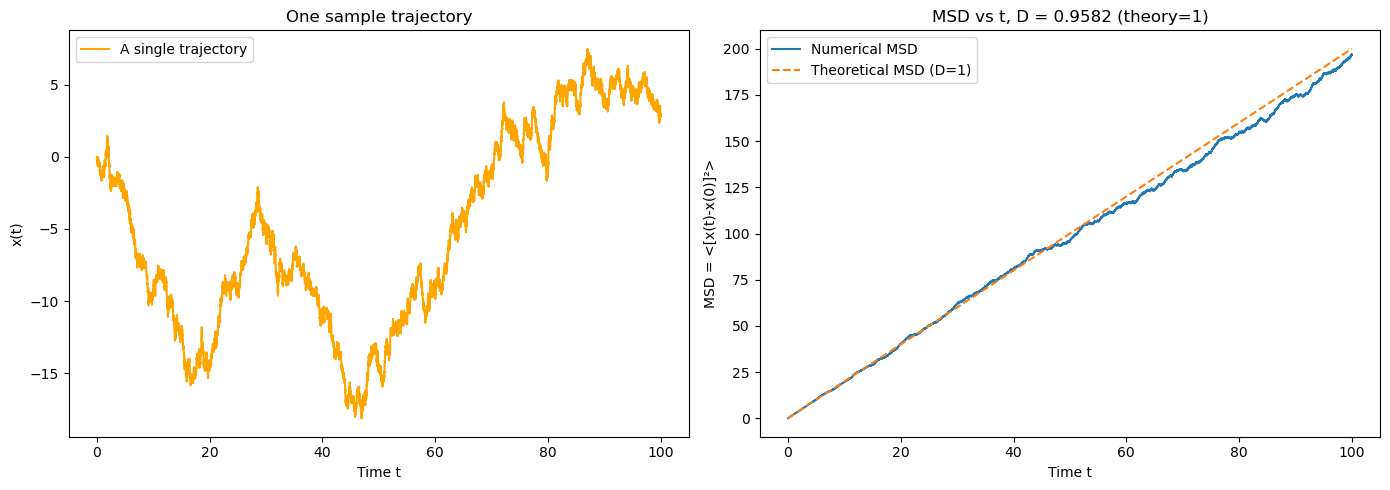

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Setup parameters
gamma = 1.0
kBT = 1.0
dt = 0.01          
total_time = 100   
n_steps = int(total_time / dt)
n_traj = 1000      # The number of n

# ========== (a) U(x) = 0 ==========
print("Running part (a): Free diffusion...")

# Save MSD results
msd_list = np.zeros(n_steps)
one_traj = np.zeros(n_steps)  

for n in range(n_traj):  
    x = 0.0  
    traj = np.zeros(n_steps)  
    for i in range(n_steps):  
        noise = np.random.normal(0, 1)  
        x += np.sqrt(2 * kBT / gamma * dt) * noise  
        traj[i] = x  
    msd_list += traj**2   # 每一条轨迹末端都加上本次结果  

    if n == 0:  
        one_traj = traj.copy() 


msd_avg = msd_list / n_traj  
time_array = np.linspace(0, total_time, n_steps)  

# 计算扩散系数  
from scipy.stats import linregress  
slope, intercept, r_value, p_value, std_err = linregress(time_array, msd_avg)  
D_numerical = slope / 2  
print(f"Numerical D = {D_numerical:.4f}, Theoretical D = {kBT/gamma:.4f}")  

 
plt.figure(figsize=(14, 5))  

# (1) 粒子轨迹  
plt.subplot(1, 2, 1)  
plt.plot(time_array, one_traj, label='A single trajectory', color='orange')  
plt.xlabel('Time t')  
plt.ylabel('x(t)')  
plt.title('One sample trajectory')  
plt.legend()  

# (2) MSD  
plt.subplot(1, 2, 2)  
plt.plot(time_array, msd_avg, label='Numerical MSD')  
plt.plot(time_array, 2 * (kBT/gamma) * time_array, '--', label='Theoretical MSD (D=1)')  
plt.xlabel('Time t')  
plt.ylabel('MSD = <[x(t)-x(0)]²>')  
plt.legend()  
plt.title(f'MSD vs t, D = {D_numerical:.4f} (theory=1)')  

plt.tight_layout()  
plt.savefig('hw2_qa.png')  
plt.show()  

Running part (b): Harmonic trap...
Numerical variance = 0.9901, Theoretical variance = 1.0


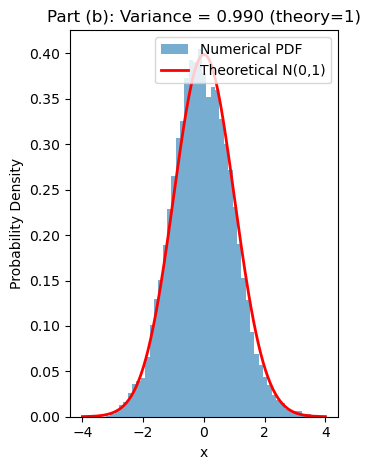

In [2]:
# ========== (b) U(x) = x²/2 ==========
print("Running part (b): Harmonic trap...")

# Simulate long trajectory to get PDF
x = 0.0
positions = []
n_steps_long = int(1000 / dt)  # Total time 1000

for i in range(n_steps_long):
    U_prime = x  # dU/dx = x
    noise = np.random.normal(0, 1)
    x += (-U_prime / gamma) * dt + np.sqrt(2 * kBT / gamma * dt) * noise
    if i > n_steps_long // 2:  # Only record second half to ensure equilibrium
        positions.append(x)

positions = np.array(positions)
var_numerical = np.var(positions)
print(f"Numerical variance = {var_numerical:.4f}, Theoretical variance = 1.0")

# Draw PDF results
plt.subplot(1, 2, 2)
count, bins, _ = plt.hist(positions, bins=50, density=True, alpha=0.6, label='Numerical PDF')

# Theoretical PDF
x_theory = np.linspace(-4, 4, 200)
p_theory = (1/np.sqrt(2*np.pi)) * np.exp(-x_theory**2 / 2)
plt.plot(x_theory, p_theory, 'r-', lw=2, label='Theoretical N(0,1)')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.title(f'Part (b): Variance = {var_numerical:.3f} (theory=1)')

plt.tight_layout()
plt.savefig('hw2_qb.png')
plt.show()